In [1]:
from transformers import AutoModelForVision2Seq, AutoProcessor
from PIL import Image
import torch

processor = AutoProcessor.from_pretrained("openvla/openvla-7b", trust_remote_code=True)
vla = AutoModelForVision2Seq.from_pretrained(
    "openvla/openvla-7b",
    attn_implementation="flash_attention_2",  # или "sdpa" без flash-attn
    torch_dtype=torch.bfloat16,
    low_cpu_mem_usage=True,
    trust_remote_code=True,
).to("cuda:0")

/home/nikitinag/experiment/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-05-21 18:23:08.827319: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-21 18:23:08.857412: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-05-21 18:23:08.857430: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-05-21 18:23:0

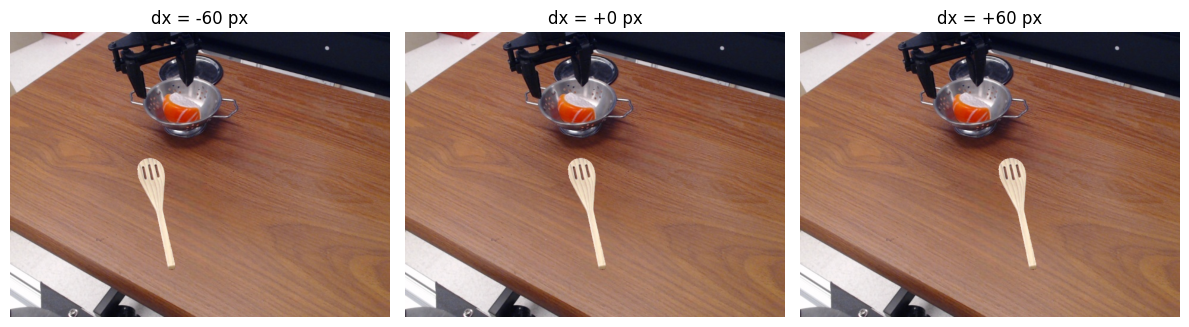

In [2]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from image_shift import (
    prepare_shift_on_background,
    composite_on_background,
    make_dx_range,
    run_shift_sweep,
    results_to_arrays,
)

ORIGINAL = "images/image_original.jpg"
MASK = "images/image_mask.png"
BACKGROUND = "images/image_background.png"

background, object_layer, geo = prepare_shift_on_background(
    ORIGINAL, MASK, BACKGROUND
)

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
for ax_i, dx in zip(ax, (-60, 0, 60)):
    ax_i.imshow(composite_on_background(background, object_layer, dx))
    ax_i.set_title(f"dx = {dx:+d} px")
    ax_i.axis("off")
plt.tight_layout()
plt.show()

In [3]:
prompt = "In: What action should the robot take to pick up the wooden slotted spatula?\nOut:"
w, _ = background.size
dx_list = make_dx_range(-60, 60, step=5, image_width=w, bbox=object_layer.bbox)

results = run_shift_sweep(
    vla,
    processor,
    dx_list,
    prompt,
    background=background,
    object_layer=object_layer,
    unnorm_key="bridge_orig",
    save_dir="outputs/shift_sweep",
)
dx_px, actions = results_to_arrays(results)

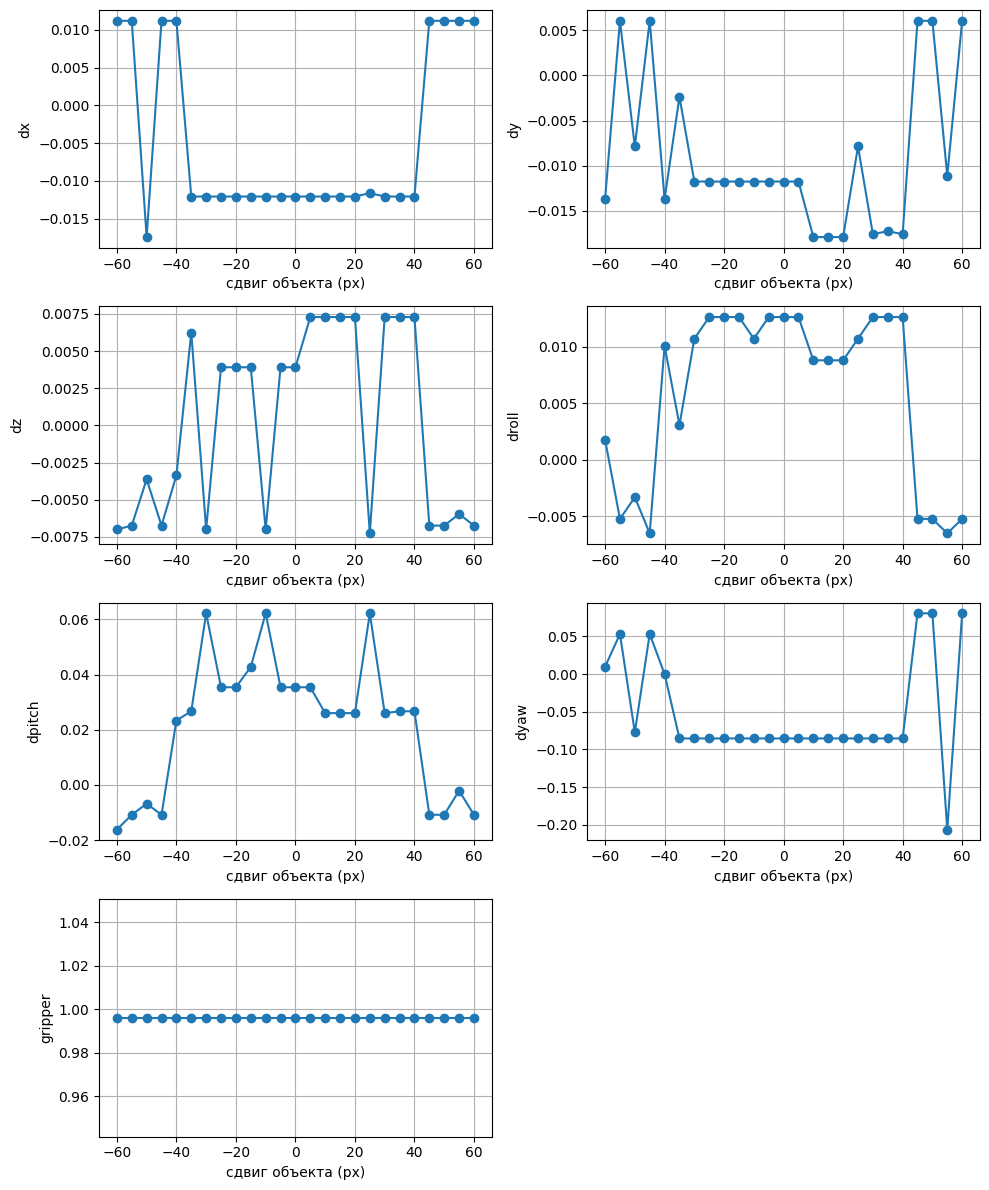

In [4]:
labels = ["dx", "dy", "dz", "droll", "dpitch", "dyaw", "gripper"]
fig, axes = plt.subplots(4, 2, figsize=(10, 12))
axes = axes.ravel()
for i, name in enumerate(labels):
    axes[i].plot(dx_px, actions[:, i], "o-")
    axes[i].set_xlabel("сдвиг объекта (px)")
    axes[i].set_ylabel(name)
    axes[i].grid(True)
axes[-1].axis("off")
plt.tight_layout()
plt.show()

In [5]:
prompt = "In: What action should the robot take to pick up the stainless steel colander?\nOut:"
w, _ = background.size
dx_list = make_dx_range(-60, 60, step=5, image_width=w, bbox=object_layer.bbox)

results = run_shift_sweep(
    vla,
    processor,
    dx_list,
    prompt,
    background=background,
    object_layer=object_layer,
    unnorm_key="bridge_orig",
    save_dir="outputs/shift_sweep",
)
dx_px, actions = results_to_arrays(results)

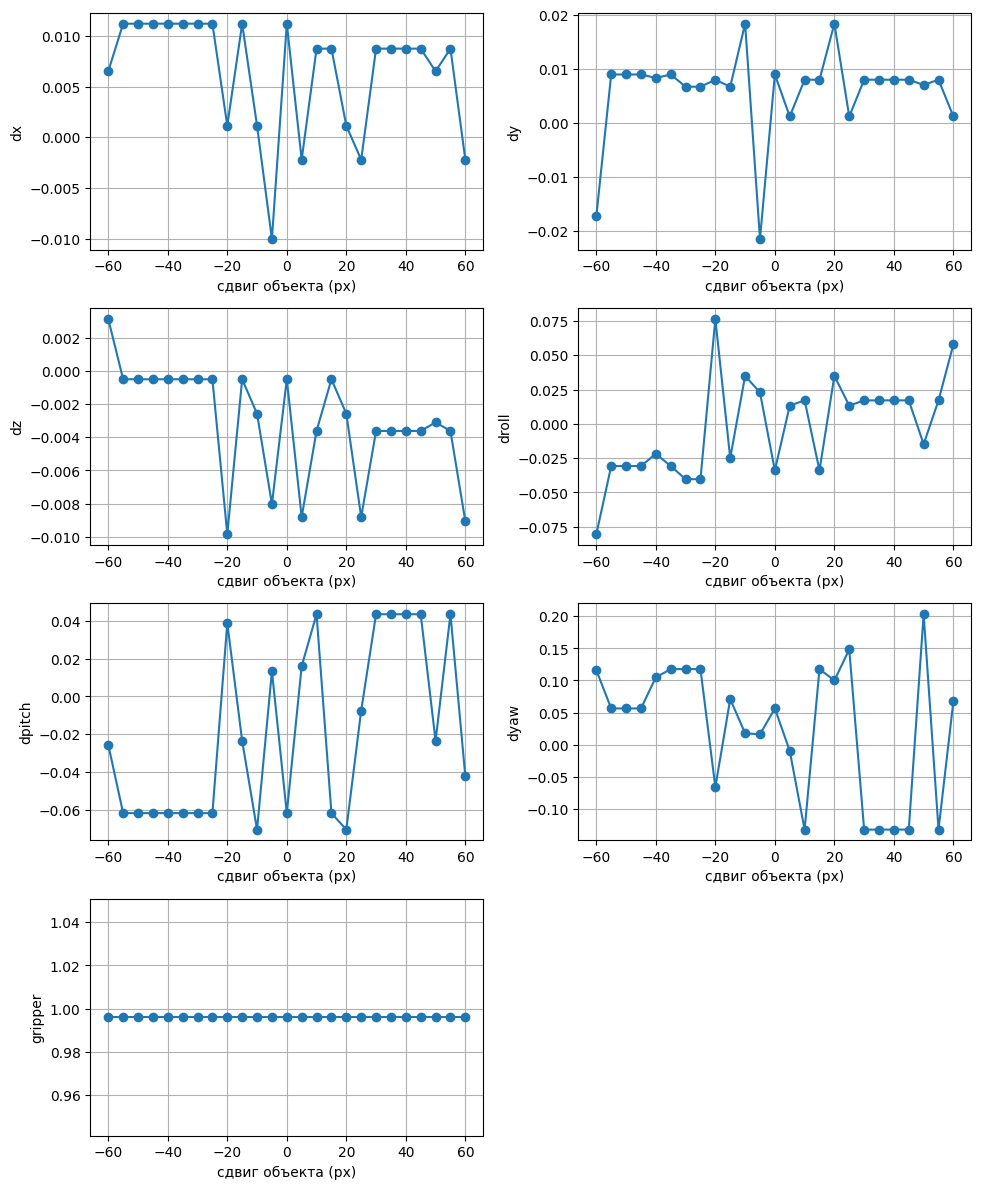

In [6]:
labels = ["dx", "dy", "dz", "droll", "dpitch", "dyaw", "gripper"]
fig, axes = plt.subplots(4, 2, figsize=(10, 12))
axes = axes.ravel()
for i, name in enumerate(labels):
    axes[i].plot(dx_px, actions[:, i], "o-")
    axes[i].set_xlabel("сдвиг объекта (px)")
    axes[i].set_ylabel(name)
    axes[i].grid(True)
axes[-1].axis("off")
plt.tight_layout()
plt.show()